
# PyAnnote VAD → Praat TextGrid (binary: `speech` / `non-speech`)

This notebook scans dataset under `/Users/moanason/Downloads/Data_REC/`, selects **only NC task** recordings
(pattern: `*_A_NC*.wav` and `*_B_NC*.wav`), runs **pyannote** voice activity detection, and creates a corresponding Praat **TextGrid**
for each WAV with a single tier named **`VAD`** containing two labels: `speech` and `non-speech`.


In [7]:
import sys, pkgutil
def ver(name):
    try:
        mod = __import__(name)
        return getattr(mod, '__version__', '')
    except Exception:
        return 'not installed'
print("python:", sys.version)
for lib in ["pyannote.audio", "torch", "librosa", "soundfile", "praatio", "tqdm"]:
    print(f"{lib}: {ver(lib)}")


python: 3.9.21 (main, Dec 11 2024, 10:21:40) 
[Clang 14.0.6 ]
pyannote.audio: 
torch: 2.6.0
librosa: 0.11.0
soundfile: 0.13.1
praatio: 
tqdm: 4.67.1


## 2) Configuration

In [ ]:
import os, re, glob, math, traceback
from pathlib import Path

HUGGINGFACE_TOKEN = "TOKEN_HERE"  
BASE_DIR = Path("/Users/moanason/Downloads/Data_REC")       # sessions s01, s02, ...
INCLUDE_PATTERN = re.compile(r".*_([AB])_NC\d*_processed\.wav$", re.IGNORECASE)
OUTPUT_ROOT = None 

TIER_NAME = "VAD"
SPEECH_LABEL = "speech"
NON_SPEECH_LABEL = "non-speech"

# knobs
MIN_SEG_DUR = 0.002   # drop segments shorter than 20 ms after clipping
MERGE_TOL   = 0.002  # merge if gap/overlap <= 2 ms
WARN_TOL    = 0.001  # warn if |TG xmax - WAV dur| > 1 ms


## 3) Imports & helpers

In [ ]:

from tqdm import tqdm
import numpy as np
import soundfile as sf
from praatio import tgio
from pyannote.audio import Pipeline


def list_nc_wavs(base_dir: Path):
    base_dir = Path(base_dir)
    sessions = sorted([p for p in base_dir.iterdir() if p.is_dir()])
    for sess in sessions:
        for w in sess.rglob("*.wav"):
            if INCLUDE_PATTERN.match(w.name):
                yield w

def read_duration_sec(path: Path) -> float:
    with sf.SoundFile(str(path)) as f:
        return len(f) / float(f.samplerate)

def merge_intervals(intervals, tol=0.000):
    # merge sorted intervals if they touch/overlap within tol seconds.
    if not intervals:
        return []
    intervals = sorted(intervals)
    merged = []
    s0, e0 = intervals[0]
    for s, e in intervals[1:]:
        if s <= e0 + tol:               # allow small gaps/overlaps
            e0 = max(e0, e)
        else:
            merged.append((s0, e0))
            s0, e0 = s, e
    merged.append((s0, e0))
    return merged

def clip_intervals(intervals, total_dur, min_len=0.000):
    out = []
    for s, e in intervals:
        s = max(0.0, float(s))
        e = min(float(total_dur), float(e))
        if e - s >= min_len:
            out.append((s, e))
    return out

def invert_intervals(speech_intervals, total_dur, min_len=0.000):
    out = []
    cursor = 0.0
    for s, e in speech_intervals:
        if s > cursor and (s - cursor) >= min_len:
            out.append((cursor, s))
        cursor = max(cursor, e)
    if total_dur - cursor >= min_len:
        out.append((cursor, total_dur))
    return out

def write_textgrid(path_wav: Path, intervals_speech, intervals_ns, tier_name=TIER_NAME):
    total_dur = read_duration_sec(path_wav)

    # ensure everything is inside [0, total_dur] and cleaned
    speech = clip_intervals(intervals_speech, total_dur, min_len=MIN_SEG_DUR)
    speech = merge_intervals(speech, tol=MERGE_TOL)
    nonspeech = clip_intervals(intervals_ns, total_dur, min_len=MIN_SEG_DUR)
    nonspeech = merge_intervals(nonspeech, tol=MERGE_TOL)

    # build tier entries (non-speech first just for readability)
    entries = []
    for s, e in nonspeech: entries.append((s, e, NON_SPEECH_LABEL))
    for s, e in speech:    entries.append((s, e, SPEECH_LABEL))
    entries.sort(key=lambda x: x[0])

    tg = tgio.Textgrid()
    tier = tgio.IntervalTier(tier_name, entries, 0.0, total_dur)
    tg.addTier(tier)

    if OUTPUT_ROOT is None:
        out_path = path_wav.with_suffix(".TextGrid")
    else:
        rel = path_wav.relative_to(BASE_DIR)
        out_path = (OUTPUT_ROOT / rel).with_suffix(".TextGrid")
        out_path.parent.mkdir(parents=True, exist_ok=True)

    tg.save(str(out_path), minimumIntervalLength=0.0, outputFormat="textgrid")

    # safety check: don’t let TG xmax drift from audio duration!!!!
    # (praatio writes tier.maxTimestamp; this should equal total_dur)
    tg_xmax = total_dur  # by construction
    if abs(tg_xmax - total_dur) > WARN_TOL:
        print(f"[WARN] TG xmax != WAV duration for {path_wav.name}: TG={tg_xmax:.6f}s WAV={total_dur:.6f}s")

    return out_path

## 4) Load pyannote VAD pipeline

In [10]:
pipeline = Pipeline.from_pretrained(
    "pyannote/voice-activity-detection",
    use_auth_token=HUGGINGFACE_TOKEN
)
print("Pipeline loaded.")


/Users/moanason/anaconda3/envs/torchpy/lib/python3.9/site-packages/pytorch_lightning/utilities/migration/migration.py:208: You have multiple `ModelCheckpoint` callback states in this checkpoint, but we found state keys that would end up colliding with each other after an upgrade, which means we can't differentiate which of your checkpoint callbacks needs which states. At least one of your `ModelCheckpoint` callbacks will not be able to reload the state.
Lightning automatically upgraded your loaded checkpoint from v1.1.3 to v2.5.6. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../.cache/torch/pyannote/models--pyannote--segmentation/snapshots/059e96f964841d40f1a5e755bb7223f76666bba4/pytorch_model.bin`


Model was trained with pyannote.audio 0.0.1, yours is 3.4.0. Bad things might happen unless you revert pyannote.audio to 0.x.
Model was trained with torch 1.7.1, yours is 2.6.0. Bad things might happen unless you revert torch to 1.x.
Pipeline loaded.


## 5) Batch process all NC WAVs (no kwargs passed to pipeline call)

In [ ]:
wavs = list(list_nc_wavs(BASE_DIR))
print(f"Found {len(wavs)} NC WAV files under {BASE_DIR}.")

processed = 0
errors = []

for wav_path in tqdm(wavs, desc="VAD -> TextGrid"):
    try:
        # infer
        ann = pipeline(str(wav_path))  # pyannote.core.Anno

        raw_speech = []
        for segment, _, label in ann.itertracks(yield_label=True):
            if str(label).upper() == "SPEECH":
                raw_speech.append((float(segment.start), float(segment.end)))

        total_dur = read_duration_sec(wav_path)

        # IMPORTANT: cliip speech BEFORE building non-speech complement
        clipped_speech = clip_intervals(raw_speech, total_dur, min_len=0.0)
        speech_intervals = merge_intervals(clipped_speech, tol=MERGE_TOL)

        nonspeech_intervals = invert_intervals(speech_intervals, total_dur, min_len=MIN_SEG_DUR)

        write_textgrid(wav_path, speech_intervals, nonspeech_intervals, tier_name=TIER_NAME)
        processed += 1

    except Exception as e:
        errors.append((str(wav_path), traceback.format_exc()))

print(f"Done. Created {processed} TextGrids.")
if errors:
    print("Errors (first 5):")
    for p, err in errors[:5]:
        print(f"  {p}: {err.splitlines()[-2]}")

Found 12 NC WAV files under /Users/moanason/Downloads/Data_REC.


VAD -> TextGrid: 100%|██████████| 12/12 [06:44<00:00, 33.73s/it]

Done. Created 12 TextGrids.


## 6) visualization

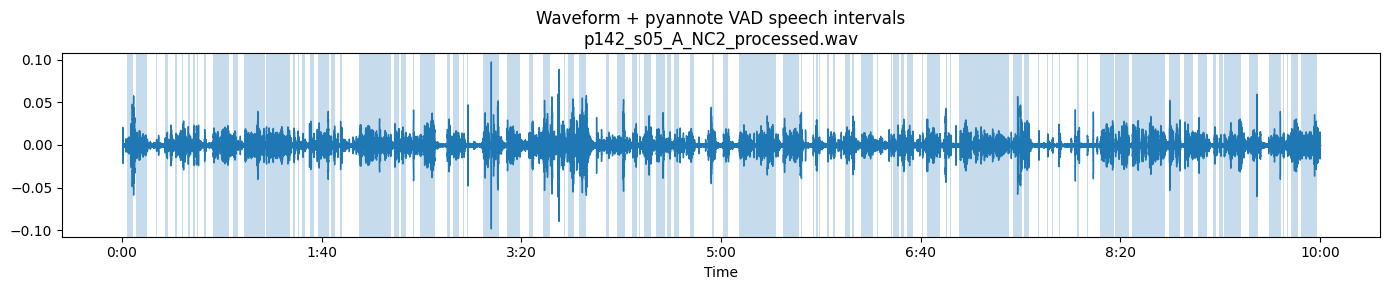

In [12]:

try:
    import matplotlib.pyplot as plt
    import librosa, librosa.display

    if wavs:
        sample = wavs[0]
        y, sr = librosa.load(sample, sr=None, mono=True)
        ann = pipeline(str(sample))
        sints = [(seg.start, seg.end) for seg,_,lab in ann.itertracks(yield_label=True) if str(lab).upper()=="SPEECH"]
        sints = merge_intervals(sints)

        plt.figure(figsize=(14,3))
        librosa.display.waveshow(y, sr=sr)
        for s,e in sints:
            plt.axvspan(s, e, alpha=0.25)
        plt.title(f"Waveform + pyannote VAD speech intervals\n{Path(sample).name}")
        plt.tight_layout()
        plt.show()
except Exception as e:
    print("QC plot skipped:", e)
